# The Death Cross ✝️
### When the 50-day average drops below the 200-day, is it really time to sell?

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Dodges crashes?: Confirmed](https://img.shields.io/badge/Dodges_crashes%3F-Confirmed-8b949e?style=flat-square)

Every time the 50-day moving average crosses below the 200-day, financial TV calls it a *death cross* and asks whether the crash has begun. We take the rule literally — out of the market below the cross, back in above it — and ask the only two questions that matter: does it **dodge the crashes** (yes), and does it **beat just holding the index** (no).

> 📓 **This is the plain-language layer.** The statistics, the matched-coin control and the capacity maths are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Not investment advice.** Educational, reproducible research — every chart below is generated by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study root (death_cross/)
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
from death_cross import data, strategy

AS_OF = "2026-06-12"
frame = data.load_real("SPY", mode="total_return").loc[:AS_OF]
close = frame["close"]
pos = strategy.crossover_position(close, 50, 200, lag=1)
timer = strategy.backtest(close, pos, cost_bps=5.0)
bh = strategy.buy_and_hold(close)
print(f"SPY total return: {len(close):,} rows  {close.index[0].date()} -> {close.index[-1].date()}  fingerprint={data.fingerprint(frame)}")
print(f"timer  Sharpe {timer['sharpe']:.3f}  maxDD {timer['max_dd']*100:.1f}%  CAGR {timer['cagr']*100:.2f}%  TiM {timer['time_in_market']*100:.0f}%")
print(f"B&H    Sharpe {bh['sharpe']:.3f}  maxDD {bh['max_dd']*100:.1f}%  CAGR {bh['cagr']*100:.2f}%")


SPY total return: 8,400 rows  1993-01-29 -> 2026-06-12  fingerprint=c43269c9d2be
timer  Sharpe 0.743  maxDD -33.7%  CAGR 9.64%  TiM 75%
B&H    Sharpe 0.646  maxDD -55.2%  CAGR 10.82%


## The answer first 🎯

| Question | Answer |
|---|---|
| Does the death cross dodge the big crashes? | **Yes** — worst drop **-33.7%** vs **-55.2%** for buy-and-hold (a **22-point** cut). |
| Does it beat just holding the index? | **No** — it earns **9.64%/yr** vs **10.82%/yr**, about **1.2 points/yr less**. |
| So what *is* it? | A way to hold **less stock** (75% of the time invested), i.e. less risk — not a way to make more money. |

## 1 · The claim

*"When the 50-day average crosses below the 200-day — the **death cross** — get out. Re-enter on the **golden cross**. You'll sidestep the bear markets and beat buy-and-hold."* It's one of the most-repeated rules in market commentary.

## 2 · So what?

If a rule this simple really beat the index, indexing would be a mistake and every investor should run it. The stakes are exactly that big — so it deserves a fair, literal test rather than a cherry-picked chart of 2008.

## 3 · How would we even know?

We hold SPY (dividends included) while the 50-day SMA is above the 200-day, sit in cash otherwise, act **one day after** each cross (no peeking), and pay **5 bps** per switch. Then we line it up against two yardsticks: **buy-and-hold**, and a **random coin** that is out of the market for the *same total time, in similar-length stretches*, but on random dates. If the cross is just *"be in cash sometimes"*, it won't beat the coin.

## 4 · The teardown — let's actually look

First, the equity curves and the drawdowns.

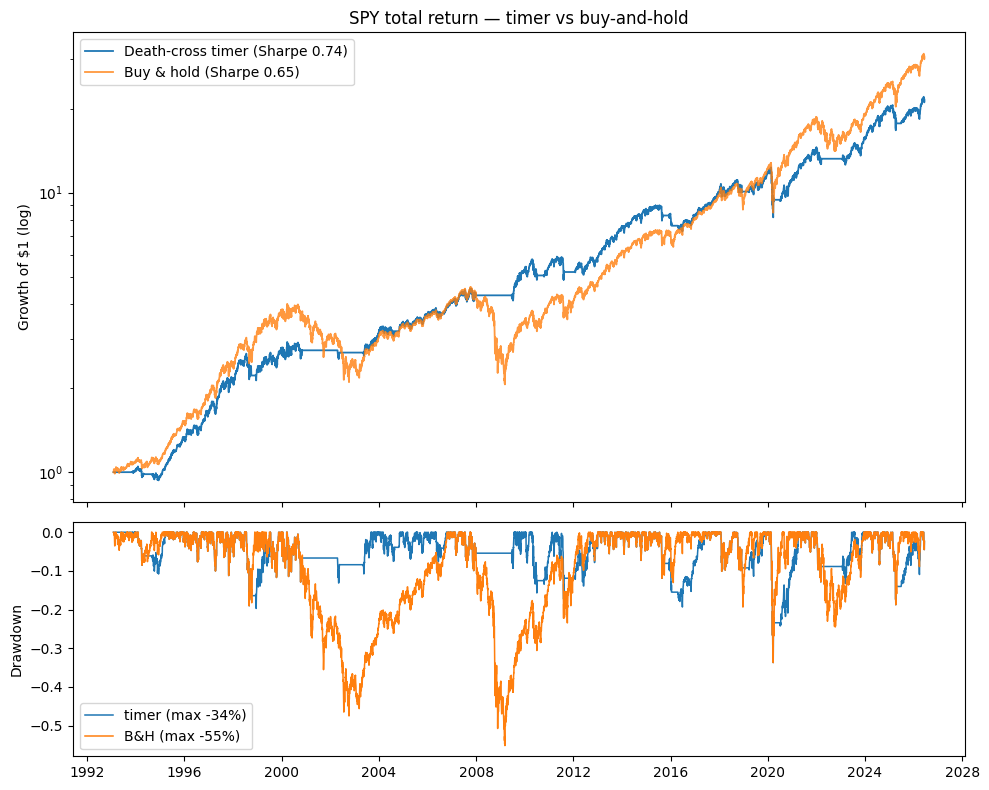

In [2]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True, height_ratios=[2, 1])
ax1.plot(timer['equity'], label=f"Death-cross timer (Sharpe {timer['sharpe']:.2f})", lw=1.3)
ax1.plot(bh['equity'], label=f"Buy & hold (Sharpe {bh['sharpe']:.2f})", lw=1.3, alpha=.8)
ax1.set_yscale('log'); ax1.set_ylabel('Growth of $1 (log)'); ax1.legend(); ax1.set_title('SPY total return — timer vs buy-and-hold')
for d, lab in [(timer, 'timer'), (bh, 'B&H')]:
    eq = d['equity']; dd = eq/eq.cummax()-1
    ax2.plot(dd, label=f"{lab} (max {dd.min()*100:.0f}%)", lw=1.1)
ax2.set_ylabel('Drawdown'); ax2.legend(); ax2.set_xlabel('')
plt.tight_layout(); plt.show()

The timer's line is *smoother* — it ducks the 2000–02 and 2008 craters. But look at the **end point**: buy-and-hold finishes higher. You paid for the calmer ride with return.

Now the **matched random coin** — is the cross better than random in/out of the same amount?

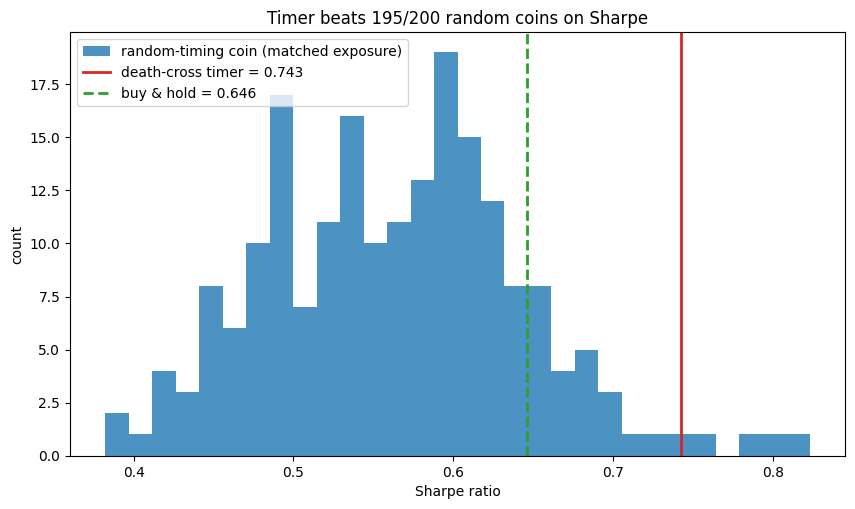

timer beats 195/200 matched random coins


In [3]:
rand = []
for s in range(200):
    rp = strategy.matched_random_position(pos, seed=s)
    rand.append(strategy.backtest(close, rp, cost_bps=5.0)['sharpe'])
rand = np.array(rand)
plt.hist(rand, bins=30, alpha=.8, label='random-timing coin (matched exposure)')
plt.axvline(timer['sharpe'], color='C3', lw=2, label=f"death-cross timer = {timer['sharpe']:.3f}")
plt.axvline(bh['sharpe'], color='C2', lw=2, ls='--', label=f"buy & hold = {bh['sharpe']:.3f}")
plt.xlabel('Sharpe ratio'); plt.ylabel('count'); plt.legend()
plt.title(f"Timer beats {(timer['sharpe']>rand).sum()}/200 random coins on Sharpe"); plt.show()
print(f"timer beats {(timer['sharpe']>rand).sum()}/200 matched random coins")

The timer beats **195/200** random coins (98%): the crossover *dates* genuinely carry information — it's not luck and it's not merely being in cash. The crash-dodging is **real**.

## 5 · The verdict

- **Dodges crashes? → Confirmed.** Drawdown -33.7% vs -55.2%, vol 13.7% vs 18.6%, and it beats a matched coin 98% of the time.
- **Signal → Weak.** The Sharpe edge over buy-and-hold is only **+0.097** and the return *difference* isn't statistically distinguishable from zero (HAC *t* = -0.99).
- **Beats the market? → Mirage.** It earns **1.2 pts/yr less**. What you're really buying is lower exposure — less beta — not skill.

## 6 · Could you actually trade it?

You can — it's just SPY, infinitely liquid. The problem isn't capacity, it's that the product is *less return for less risk*, which you can get more cheaply by simply holding less stock and more cash (or bonds). Add the **taxes** on 31 taxable switches and the gap widens. As *"a rule that beats the index,"* it's a mirage.

## 7 · Going further 🚪

- Does earning the **T-bill** in cash (instead of 0%) close the return gap? (It helps, but it's still de-risking, not alpha.)
- Other pairs (20/100, 100/200) — do faster crosses whipsaw more?
- Is the drawdown cut worth more in a **leveraged** sleeve? Fork it and try.